# Étape 4 — Optimisation des hyperparamètres & Seuil métier
## Projet MLOps — Home Credit Default Risk

**Objectif :**  
- Optimiser les hyperparamètres d'XGBoost avec Optuna  
- Réévaluer avec validation croisée  
- Ajuster le seuil métier sur le modèle optimisé  
- Enregistrer le nouveau champion dans MLflow

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import optuna
import mlflow
import mlflow.xgboost
from mlflow import MlflowClient

# ── Configuration MLflow ──────────────────────────────────────────────────────
MLFLOW_URI  = 'sqlite:////home/veron/Documents/OpenClassRoom/p6/mlflow.db'
DATA_PATH   = '/home/veron/Documents/OpenClassRoom/p6/dataset/'
MODEL_NAME  = 'home_credit_scoring'
EXPERIMENT  = 'P6_HomeCreditRisk'

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)

print('✅ Imports OK')
print(f'MLflow URI : {MLFLOW_URI}')

✅ Imports OK
MLflow URI : sqlite:////home/veron/Documents/OpenClassRoom/p6/mlflow.db


## 1. Chargement des données & suppression de SK_ID_CURR

> **Data leakage** : `SK_ID_CURR` est un identifiant client sans valeur prédictive.  
> Sa présence dans les features fausse les importances et peut introduire du sur-apprentissage.  
> On le supprime avant tout entraînement.

In [2]:
# ── Chargement ────────────────────────────────────────────────────────────────
train = pd.read_parquet(DATA_PATH + 'app_train_clean.parquet')
print(f'Dataset chargé : {train.shape[0]:,} lignes × {train.shape[1]} colonnes')

# ── Suppression SK_ID_CURR ────────────────────────────────────────────────────
if 'SK_ID_CURR' in train.columns:
    train = train.drop(columns=['SK_ID_CURR'])
    print('✅ SK_ID_CURR supprimé (data leakage)')
else:
    print('ℹ️  SK_ID_CURR absent du dataset')

# ── Séparation features / cible ───────────────────────────────────────────────
X = train.drop(columns=['TARGET'])
y = train['TARGET']

print(f'\nFeatures : {X.shape[1]} colonnes')
print(f'Distribution TARGET : {y.value_counts(normalize=True).round(3).to_dict()}')

Dataset chargé : 307,511 lignes × 250 colonnes
ℹ️  SK_ID_CURR absent du dataset

Features : 249 colonnes
Distribution TARGET : {0: 0.919, 1: 0.081}


In [3]:
# ── Split train / validation ──────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f'X_train : {X_train.shape} | X_val : {X_val.shape}')

X_train : (246008, 249) | X_val : (61503, 249)


## 2. Fonction coût métier

> **Rappel contexte** :  
> - **Faux Négatif (FN)** : mauvais client prédit bon → crédit accordé → perte en capital → coût = 10  
> - **Faux Positif (FP)** : bon client prédit mauvais → crédit refusé → manque à gagner → coût = 1  
> 
> Le coût FN est supposé 10× supérieur au coût FP.

In [4]:
def cout_metier(y_true, y_proba, seuil=0.5, cout_fn=10, cout_fp=1):
    """Calcule le coût métier normalisé pour un seuil donné."""
    y_pred = (y_proba >= seuil).astype(int)
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    cout = (fn * cout_fn + fp * cout_fp) / len(y_true)
    return cout


def optimiser_seuil(y_true, y_proba, seuils=None):
    """Teste plusieurs seuils et retourne le seuil optimal + DataFrame des coûts."""
    if seuils is None:
        seuils = np.arange(0.05, 0.95, 0.01)
    rows = []
    for s in seuils:
        y_pred = (y_proba >= s).astype(int)
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        rows.append({
            'seuil': round(s, 2),
            'fn': fn,
            'fp': fp,
            'cout_metier': (fn * 10 + fp * 1) / len(y_true)
        })
    df = pd.DataFrame(rows)
    seuil_opt = df.loc[df['cout_metier'].idxmin(), 'seuil']
    return seuil_opt, df


print('✅ Fonctions coût métier définies')

✅ Fonctions coût métier définies


## 3. Optimisation des hyperparamètres — Optuna

On utilise **Optuna** pour trouver les meilleurs hyperparamètres d'XGBoost.  
La fonction objectif minimise l'opposé de l'AUC (Optuna minimise par défaut).  
Chaque trial est évalué avec une validation croisée **StratifiedKFold(3)**.

In [5]:
# ── Fonction objectif Optuna ──────────────────────────────────────────────────
def objective(trial):
    """Fonction objectif : maximise l'AUC par cross-validation."""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': 12,   # déséquilibre des classes (~8% défauts)
        'random_state'    : 42,
        'eval_metric'     : 'auc',
        'verbosity'       : 0,
    }
    model = XGBClassifier(**params)
    skf   = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    return scores.mean()


# ── Lancement de l'étude Optuna ───────────────────────────────────────────────
# n_trials=20 pour un bon compromis vitesse / qualité
# Augmenter à 50+ si le temps le permet
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize', study_name='xgboost_home_credit')
study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f'\n✅ Optimisation terminée')
print(f'Meilleur AUC CV : {study.best_value:.4f}')
print(f'Meilleurs paramètres :')
for k, v in study.best_params.items():
    print(f'  {k} : {v}')

Best trial: 2. Best value: 0.753352: 100%|██████████████████████████████████| 10/10 [11:10<00:00, 67.06s/it]


✅ Optimisation terminée
Meilleur AUC CV : 0.7534
Meilleurs paramètres :
  n_estimators : 278
  max_depth : 5
  learning_rate : 0.060277307941591224
  subsample : 0.9261645595137908
  colsample_bytree : 0.7996453282137117
  min_child_weight : 6


## 4. Entraînement du modèle optimisé + MLflow

In [6]:
# ── Modèle avec les meilleurs hyperparamètres ─────────────────────────────────
best_params = study.best_params
best_params.update({
    'scale_pos_weight': 12,
    'random_state'    : 42,
    'eval_metric'     : 'auc',
    'verbosity'       : 0,
})

model_opt = XGBClassifier(**best_params)

# ── Validation croisée du modèle optimisé ─────────────────────────────────────
print('Validation croisée du modèle optimisé...')
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_opt, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f'AUC par fold : {[round(s, 4) for s in cv_scores]}')
print(f'Moyenne      : {cv_scores.mean():.4f}')
print(f'Écart-type   : {cv_scores.std():.4f}')

# ── Entraînement final sur X_train complet ────────────────────────────────────
model_opt.fit(X_train, y_train)
y_proba_opt = model_opt.predict_proba(X_val)[:, 1]
auc_val     = roc_auc_score(y_val, y_proba_opt)
print(f'\nAUC validation : {auc_val:.4f}')

Validation croisée du modèle optimisé...
AUC par fold : [np.float64(0.7549), np.float64(0.7575), np.float64(0.7568)]
Moyenne      : 0.7564
Écart-type   : 0.0011

AUC validation : 0.7626


Coût @seuil=0.5  : 0.5294
Coût @seuil_opt  : 0.5266
Seuil optimal    : 0.55


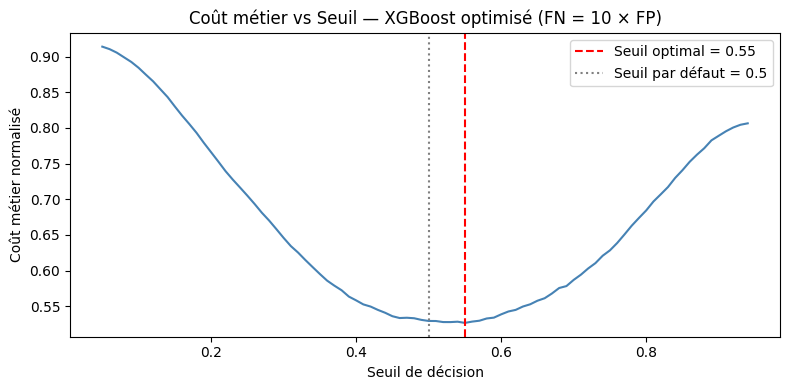

In [7]:
# ── Optimisation du seuil métier ──────────────────────────────────────────────
seuil_opt, df_couts = optimiser_seuil(y_val, y_proba_opt)
cout_opt = df_couts['cout_metier'].min()
cout_05  = cout_metier(y_val, y_proba_opt, seuil=0.5)

print(f'Coût @seuil=0.5  : {cout_05:.4f}')
print(f'Coût @seuil_opt  : {cout_opt:.4f}')
print(f'Seuil optimal    : {seuil_opt:.2f}')

# ── Courbe coût vs seuil ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(df_couts['seuil'], df_couts['cout_metier'], color='steelblue')
plt.axvline(seuil_opt, color='red', linestyle='--', label=f'Seuil optimal = {seuil_opt:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut = 0.5')
plt.xlabel('Seuil de décision')
plt.ylabel('Coût métier normalisé')
plt.title('Coût métier vs Seuil — XGBoost optimisé (FN = 10 × FP)')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ── Logging MLflow ────────────────────────────────────────────────────────────
mlflow.xgboost.autolog(disable=True)

with mlflow.start_run(run_name='XGBoost_optimise_optuna') as run:
    run_id = run.info.run_id

    # Tags
    mlflow.set_tag('modele',     'XGBoost')
    mlflow.set_tag('etape',      'optimisation_optuna')
    mlflow.set_tag('dataset',    'application_train')
    mlflow.set_tag('mlflow.note.content',
        f'XGBoost optimisé avec Optuna ({len(study.trials)} trials). '
        f'SK_ID_CURR supprimé. '
        f'scale_pos_weight=12. '
        f'Seuil métier ajusté FN=10×FP.')

    # Hyperparamètres
    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param('n_trials_optuna', len(study.trials))

    # Métriques
    mlflow.log_metric('auc_val',            auc_val)
    mlflow.log_metric('cv_auc_mean',        cv_scores.mean())
    mlflow.log_metric('cv_auc_std',         cv_scores.std())
    mlflow.log_metric('cout_seuil_05',      cout_05)
    mlflow.log_metric('cout_seuil_optimal', cout_opt)
    mlflow.log_metric('seuil_optimal',      seuil_opt)

    # Modèle
    mlflow.xgboost.log_model(
        model_opt,
        name='model',
        registered_model_name=MODEL_NAME
    )

print(f'\n✅ Run loggé : {run_id}')
print(f'AUC val     : {auc_val:.4f}')
print(f'CV AUC mean : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Coût opt    : {cout_opt:.4f} @ seuil {seuil_opt:.2f}')

2026/03/19 10:14:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



✅ Run loggé : 8641668c773445e9b0ecd2bbb09790ab
AUC val     : 0.7626
CV AUC mean : 0.7564 ± 0.0011
Coût opt    : 0.5266 @ seuil 0.55


Registered model 'home_credit_scoring' already exists. Creating a new version of this model...
Created version '5' of model 'home_credit_scoring'.


## 5. Mise à jour du champion dans le registry

In [9]:
# ── Récupération de la dernière version enregistrée ───────────────────────────
client  = MlflowClient(tracking_uri=MLFLOW_URI)
versions = client.search_model_versions(f"name='{MODEL_NAME}'")
last_version = sorted(versions, key=lambda v: int(v.version))[-1].version

print(f'Dernière version : {last_version}')

# ── Description et tags de la version ────────────────────────────────────────
client.update_model_version(
    name=MODEL_NAME,
    version=last_version,
    description=(
        f'XGBoost optimisé avec Optuna ({len(study.trials)} trials).\n'
        f'SK_ID_CURR supprimé (data leakage corrigé).\n'
        f'AUC validation : {auc_val:.4f}.\n'
        f'CV AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}.\n'
        f'Seuil métier optimal : {seuil_opt:.2f} (coût = {cout_opt:.4f}).\n'
        f'Dataset : application_train.csv.'
    )
)
client.set_model_version_tag(MODEL_NAME, last_version, 'auc_val',       f'{auc_val:.4f}')
client.set_model_version_tag(MODEL_NAME, last_version, 'cv_auc_mean',   f'{cv_scores.mean():.4f}')
client.set_model_version_tag(MODEL_NAME, last_version, 'seuil_optimal', f'{seuil_opt:.2f}')
client.set_model_version_tag(MODEL_NAME, last_version, 'optimisation',  'optuna')

# ── Alias champion ────────────────────────────────────────────────────────────
client.set_registered_model_alias(MODEL_NAME, 'champion', last_version)

print(f'✅ Version {last_version} → alias "champion"')

Dernière version : 5
✅ Version 5 → alias "champion"


## 6. Analyse des résultats

In [11]:
# ── Comparaison baseline vs modèle optimisé ───────────────────────────────────
print('=' * 55)
print('COMPARAISON BASELINE vs MODÈLE OPTIMISÉ')
print('=' * 55)
print(f"{'Métrique':<30} {'Baseline':>10} {'Optimisé':>10}")
print('-' * 55)
print(f"{'AUC CV moyenne':<30} {'0.7486':>10} {cv_scores.mean():>10.4f}")
print(f"{'Coût @seuil_opt':<30} {'0.5337':>10} {cout_opt:>10.4f}")
print(f"{'Seuil optimal':<30} {'0.525':>10} {seuil_opt:>10.3f}")
print('=' * 55)

COMPARAISON BASELINE vs MODÈLE OPTIMISÉ
Métrique                         Baseline   Optimisé
-------------------------------------------------------
AUC CV moyenne                     0.7486     0.7564
Coût @seuil_opt                    0.5337     0.5266
Seuil optimal                       0.525      0.550


## ✅ Checklist — Étape 4

| Indicateur | Statut |
|---|---|
| Optimisation hyperparamètres avec Optuna | ✅ |
| Validation croisée StratifiedKFold(3) | ✅ |
| Fonction de coût métier FN=10×FP | ✅ |
| Plusieurs seuils testés (0.05 → 0.95) | ✅ |
| Seuil optimal identifié et tracé | ✅ |
| Métriques loggées dans MLflow | ✅ |
| Modèle enregistré dans le registry | ✅ |
| Alias champion mis à jour | ✅ |